# 参数分析

在利用SVM解决具体分类或回归问题时，通过需要根据相关数据的分布形态选择合理的核函数、C与gamma值等参数并对相关结果进行可视化，进而提高分类或回归问题求解的可靠性与精度。

首先构造两类样本，然后利用SVM对其进行分类与可视化，具体要求如下：
1. 绘制不同核函数、C与gamma值时相应的分类界线。
2. 显示样本分类结果及相应的支持向量。
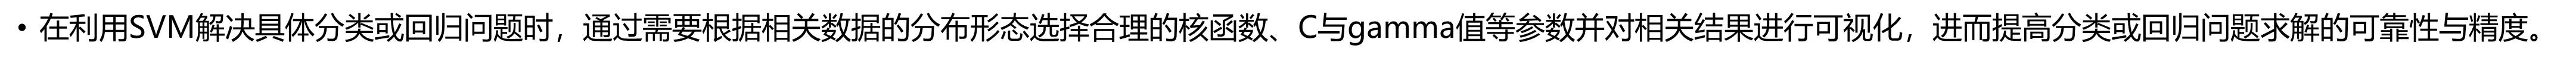
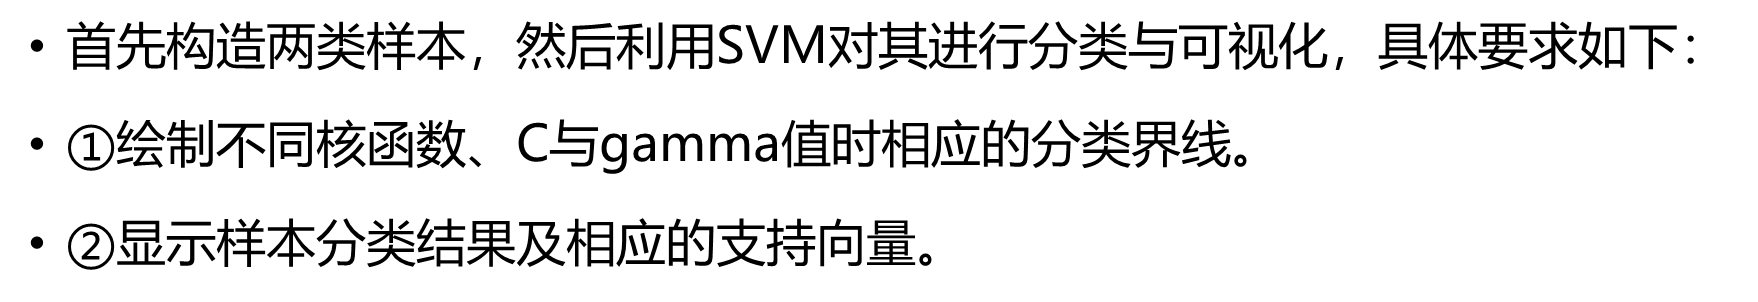
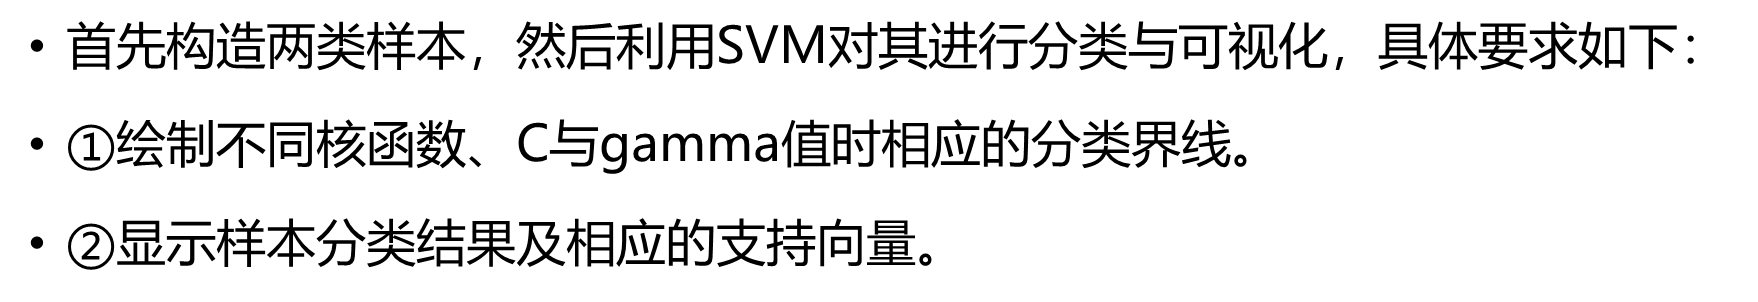

In [25]:
import numpy as np  # 导入科学计算库
import matplotlib.pyplot as plt  # 导入绘图库
from sklearn.svm import SVC  # 导入SVC模块
from sklearn.datasets import make_blobs  # 导入 make_blobs 数据库

# make_blobs 函数

make_blobs 是 scikit-learn 中用于生成聚类数据集的函数，常用于机器学习算法的测试和演示。

文档：[https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html)

函数原型：
+ sklearn.datasets.make_blobs(n_samples=100, n_features=2, *, centers=None, cluster_std=1.0, center_box=(-10.0, 10.0), shuffle=True, random_state=None, return_centers=False)

下述中意思为：**生成 50 个二维样本。中心分别为 (1,1) 和 (2,2)，标准差控制类内紧密程度。random_state=10 保证每次运行数据一致。`x` 形状为 (50, 2)，`y` 为标签 0/1。**

In [26]:
# 构造两类线性可分样本
x, y = make_blobs(n_samples=50, centers=[[1, 1], [2, 2]], cluster_std=[0.3, 0.2], random_state=10)
x

array([[2.04345303, 1.60112125],
       [2.22154165, 2.0489088 ],
       [1.6983357 , 2.12412013],
       [2.1423918 , 2.18365383],
       [1.95684202, 2.19781449],
       [1.98683043, 1.57365758],
       [1.03981249, 0.8571574 ],
       [1.37694168, 0.78040915],
       [0.65901934, 1.04054106],
       [2.06387128, 2.09218058],
       [1.120063  , 0.8987103 ],
       [1.39947595, 1.21458369],
       [0.91980484, 0.8352073 ],
       [1.99481893, 2.05781884],
       [1.12990786, 1.36091121],
       [1.97754551, 1.92756391],
       [1.07982105, 1.7154902 ],
       [1.98761759, 1.84922141],
       [1.89202419, 2.141632  ],
       [2.39701692, 2.34896283],
       [1.90358137, 2.01791752],
       [0.53637991, 0.99748485],
       [1.18640079, 0.78397433],
       [1.92750016, 1.97561886],
       [0.40668152, 0.47698831],
       [2.22575703, 1.86043799],
       [1.1695458 , 0.95577392],
       [2.16539972, 1.60909758],
       [0.7104803 , 1.30848222],
       [1.9902339 , 2.07866824],
       [1.

In [27]:
y

array([1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0])

In [28]:
# 构建SVM分类器模型
model = SVC(C=1, kernel='linear')
# 训练SVM分类器模型
model.fit(x, y)  # 初始化 SVM。kernel='linear' 表示使用线性核（找直线/超平面）；C=1 是正则化参数，控制误分类惩罚与间隔宽度的平衡。

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [29]:
# 筛选点的工程方法
print(type(x))
print("# y == 0\n", x[y == 0])  # 布尔索引
print("# y == 0, x\n", x[y == 0, 0])
print("# y == 0, y\n", x[y == 0, 1])

<class 'numpy.ndarray'>
# y == 0
 [[1.03981249 0.8571574 ]
 [1.37694168 0.78040915]
 [0.65901934 1.04054106]
 [1.120063   0.8987103 ]
 [1.39947595 1.21458369]
 [0.91980484 0.8352073 ]
 [1.12990786 1.36091121]
 [1.07982105 1.7154902 ]
 [0.53637991 0.99748485]
 [1.18640079 0.78397433]
 [0.40668152 0.47698831]
 [1.1695458  0.95577392]
 [0.7104803  1.30848222]
 [1.33710738 1.50178666]
 [1.19806947 0.89473843]
 [1.07965348 1.03256456]
 [0.75862266 0.93619071]
 [1.06858904 1.13354128]
 [1.4453611  0.67605853]
 [0.89825793 1.09365098]
 [1.00128743 0.94761994]
 [1.02974476 1.41939891]
 [0.71816999 0.85319883]
 [1.39254192 1.05850398]
 [0.9186256  1.18396126]]
# y == 0, x
 [1.03981249 1.37694168 0.65901934 1.120063   1.39947595 0.91980484
 1.12990786 1.07982105 0.53637991 1.18640079 0.40668152 1.1695458
 0.7104803  1.33710738 1.19806947 1.07965348 0.75862266 1.06858904
 1.4453611  0.89825793 1.00128743 1.02974476 0.71816999 1.39254192
 0.9186256 ]
# y == 0, y
 [0.8571574  0.78040915 1.04054106 

In [30]:
_x = np.linspace(0, 10, 5)
_y = np.linspace(2, 12, 5)

print(_x)
print(_y)

[ 0.   2.5  5.   7.5 10. ]
[ 2.   4.5  7.   9.5 12. ]


# meshgrid 网格化

+ numpy.meshgrid(*xi, copy=True, sparse=False, indexing='xy')

从坐标向量中返回一个坐标矩阵的元组。

根据一维坐标数组 x1、x2、...、xn，为 N 维标量/向量场在 N 维网格上的矢量化评估创建 N 维坐标数组。

文档：[https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html)

## 数学意义

> 它是“离散笛卡尔积”的矩阵化表示，用于将连续平面区域离散化为规则网格，从而为多元函数的向量化求值提供标准数据结构。

## 工程意义

### 点披萨

假设你要点披萨，有 2 个选择维度：
- **尺寸**：小、中、大（3 种）
- **口味**：芝士、榴莲（2 种）

你想知道所有搭配组合：

```
        芝士    榴莲
    ┌───────────────┐
 小 │ (小,芝士) (小,榴莲) │
 中 │ (中,芝士) (中,榴莲) │
 大 │ (大,芝士) (大,榴莲) │
    └───────────────┘
```

 `meshgrid` 做的就是这件事：
- 输入：`尺寸=[小,中,大]`，`口味=[芝士,榴莲]`
- 输出：两张「表格」，一张填尺寸，一张填口味，**上下对齐看就是完整搭配**

```
尺寸表格          口味表格
┌─────────┐      ┌─────────┐
│小  中  大│      │芝  芝  芝│
│小  中  大│      │榴  榴  榴│
└─────────┘      └─────────┘
```

> 自动帮你把「横坐标列表」和「纵坐标列表」交叉配对，生成一张「坐标表格」，让模型能一次性预测整个平面上每个点的分类结果。



In [31]:
yy, xx = np.meshgrid(_y, _x)

print(yy)

[[ 2.   4.5  7.   9.5 12. ]
 [ 2.   4.5  7.   9.5 12. ]
 [ 2.   4.5  7.   9.5 12. ]
 [ 2.   4.5  7.   9.5 12. ]
 [ 2.   4.5  7.   9.5 12. ]]


In [32]:
yy.ravel()

array([ 2. ,  4.5,  7. ,  9.5, 12. ,  2. ,  4.5,  7. ,  9.5, 12. ,  2. ,
        4.5,  7. ,  9.5, 12. ,  2. ,  4.5,  7. ,  9.5, 12. ,  2. ,  4.5,
        7. ,  9.5, 12. ])

In [33]:
np.vstack([xx.ravel(), yy.ravel()]).T

array([[ 0. ,  2. ],
       [ 0. ,  4.5],
       [ 0. ,  7. ],
       [ 0. ,  9.5],
       [ 0. , 12. ],
       [ 2.5,  2. ],
       [ 2.5,  4.5],
       [ 2.5,  7. ],
       [ 2.5,  9.5],
       [ 2.5, 12. ],
       [ 5. ,  2. ],
       [ 5. ,  4.5],
       [ 5. ,  7. ],
       [ 5. ,  9.5],
       [ 5. , 12. ],
       [ 7.5,  2. ],
       [ 7.5,  4.5],
       [ 7.5,  7. ],
       [ 7.5,  9.5],
       [ 7.5, 12. ],
       [10. ,  2. ],
       [10. ,  4.5],
       [10. ,  7. ],
       [10. ,  9.5],
       [10. , 12. ]])

```
假设：
  x = [1, 2, 3]        # 1D, 长度 M=3
  y = [10, 20, 30]     # 1D, 长度 N=3

经 meshgrid 后：
  X = [[1, 2, 3],      # 每一行都是 x
       [1, 2, 3],
       [1, 2, 3]]      # shape = (3, 3)

  Y = [[10,10,10],     # 每一列都是 y
       [20,20,20],
       [30,30,30]]     # shape = (3, 3)

  Z = [[z₁₁, z₁₂, z₁₃],   # Z[i,j] = f(X[i,j], Y[i,j])
       [z₂₁, z₂₂, z₂₃],
       [z₃₁, z₃₂, z₃₃]]   # shape 必须 = (3, 3)
```

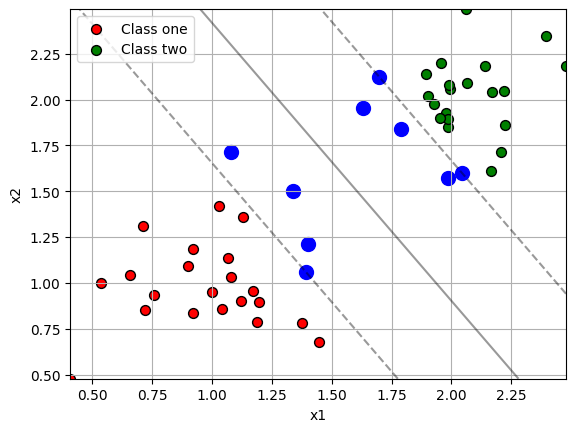

In [43]:
# 显示两类散点
plt.figure()
plt.scatter(x[y == 0, 0], x[y == 0, 1], s=50, c='r', linewidths=1, edgecolors='k', label='Class one')
plt.scatter(x[y == 1, 0], x[y == 1, 1], s=50, c='g', linewidths=1, edgecolors='k', label='Class two')

x_ = np.linspace(np.min(x[:, 0]), np.max(x[:, 0]), 50)
y_ = np.linspace(np.min(x[:, 1]), np.max(x[:, 1]), 50)

yy, xx = np.meshgrid(y_, x_)
xy = np.vstack([xx.ravel(), yy.ravel()]).T

DF = model.decision_function(xy).reshape(xx.shape)

cs = plt.contour(xx, yy, DF, colors='k', levels=[-1, 0, 1], alpha=0.4, linestyles=['--', '-', '--'])  # 画等高线图

# cs = plt.contourf(xx, yy, DF, cmap="RdYlBu_r", alpha=0.4, linestyles=['--', '-', '--'])
# plt.colorbar(cs, label='Z Value')
# plt.clabel(cs, inline=True, fontsize=9, fmt='%.2f')

# 显示支持向量
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100, linewidth=1, facecolors='b')

plt.legend(loc='best')
plt.grid(True)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [11]:
model.decision_function(xy).reshape(xx.shape)

array([[-3.71578922, -3.66197048, -3.60815174, ..., -1.18630843,
        -1.13248969, -1.07867095],
       [-3.63191791, -3.57809917, -3.52428043, ..., -1.10243712,
        -1.04861838, -0.99479964],
       [-3.54804661, -3.49422787, -3.44040913, ..., -1.01856582,
        -0.96474708, -0.91092834],
       ...,
       [ 0.22616213,  0.27998087,  0.33379961, ...,  2.75564292,
         2.80946166,  2.8632804 ],
       [ 0.31003344,  0.36385218,  0.41767092, ...,  2.83951423,
         2.89333297,  2.94715171],
       [ 0.39390474,  0.44772348,  0.50154222, ...,  2.92338553,
         2.97720427,  3.03102301]])

In [12]:
print(xy)

[[0.40668152 0.47698831]
 [0.40668152 0.51814223]
 [0.40668152 0.55929614]
 ...
 [2.47894073 2.41122238]
 [2.47894073 2.45237629]
 [2.47894073 2.49353021]]


In [13]:
model.decision_function([[2.043453, 1.601121]])  # 预测值大于 0  ，为正类

array([1.00032418])

In [14]:
model.decision_function([[1.376942, 0.780409]])  # 预测值小于 0，为负类

array([-1.39477731])

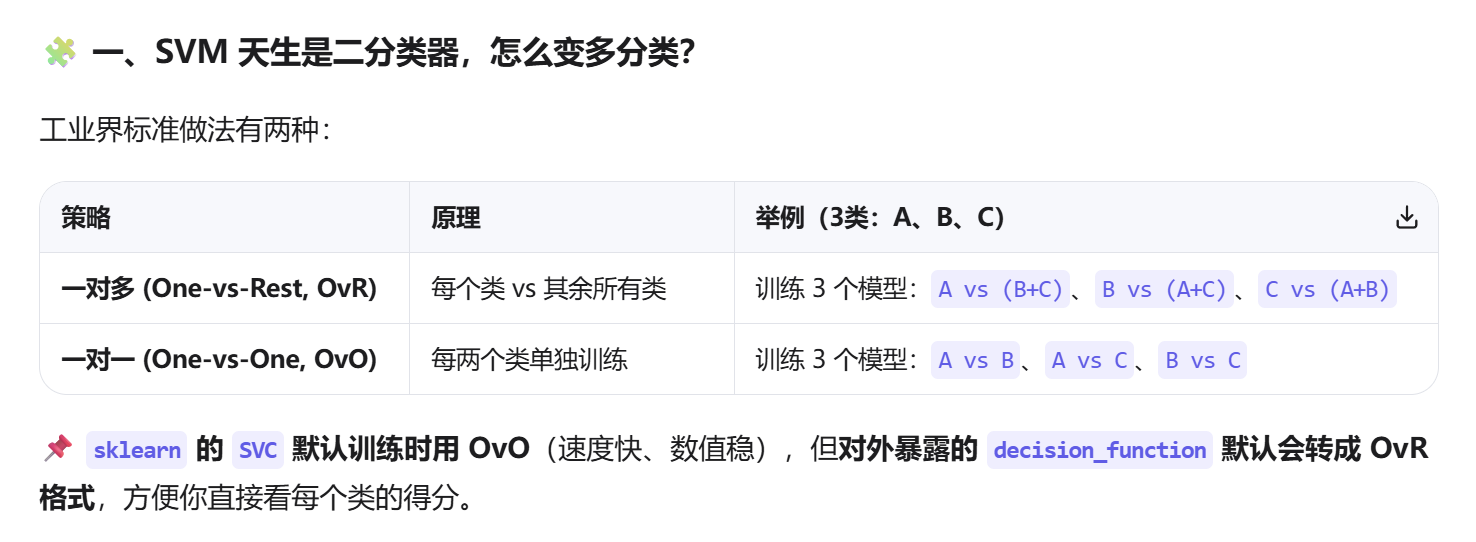

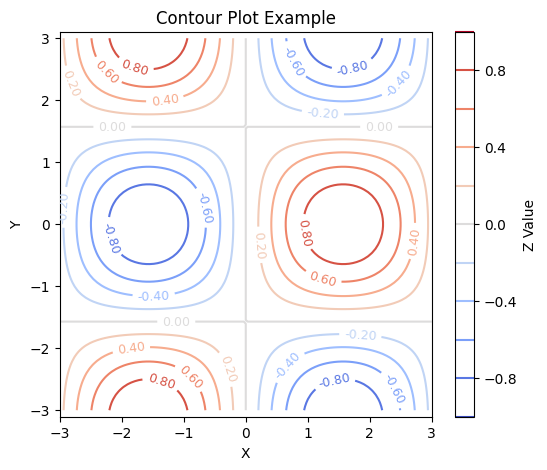

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成网格数据
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)  # 示例函数

# 2. 绘制等高线
plt.figure(figsize=(6, 5))
cs = plt.contour(X, Y, Z, levels=12, cmap='coolwarm', linewidths=1.5)

# 3. 添加色条与数值标签
plt.colorbar(cs, label='Z Value')
plt.clabel(cs, inline=True, fontsize=9, fmt='%.2f')

plt.xlabel('X'); plt.ylabel('Y')
plt.title('Contour Plot Example')
plt.axis('equal')  # 保持纵横比一致
plt.show()